# Fine-grained comparison — Qwen3.5-0.8B vs LFM2.5-VL-1.6B, per scenario

For **every probe sample** this shows, side by side: the **image**, the **question**, the **ground
truth** (with its box / rationale), and **each model's prediction + score** — to spot **flaws in the
ground truth or the metric**, not just model errors.

Data comes from the **synthetic generator** (`make_realistic_cases`) regenerated with a **fixed
`SEED`** (+ `COUNT` variants per case for many more examples), spread across *all 14 doc types* by
the `diverse` sampler. Inference runs through a **fixed-seed dataloader** in batches of `BATCH`, so
both models see **identical, reproducible** batches. Set `SELECT="understanding"` to focus on the
model-free locate/region/count/sum GT; `LIVE=False` loads cached predictions instead of running.

Heuristic flag: when **both models agree with each other but disagree with the gold**, the GT/metric
is the likely culprit — surfaced in the *GT-flaw suspects* table at the end.

In [10]:
# --- install docvlm_eval + GUARANTEE transformers>=5 (Qwen3.5-VL / LFM2.5-VL need it) ---
import os, sys, subprocess, importlib, shutil
from pathlib import Path

def _repo_root():
    for c in (Path.cwd(), Path.cwd().parent):
        if (c / "pyproject.toml").exists():
            return c
    return None

root = _repo_root()
if root is None:                       # fresh env (Colab/Kaggle): clone the repo
    subprocess.run(["git", "clone", "https://github.com/SangbumChoi/OCR.git"], check=False)
    root = Path("OCR")
    subprocess.run(["git", "-C", str(root), "checkout", "claude/new-session-w79q0i"], check=False)
    subprocess.run(["git", "-C", str(root), "pull", "--ff-only"], check=False)
os.chdir(root)
if shutil.which("apt-get"):
    subprocess.run(["apt-get", "update", "-qq"], check=False)
    subprocess.run(["apt-get", "install", "-y", "-qq", "libpango-1.0-0", "libpangoft2-1.0-0",
                    "libharfbuzz0b", "libfontconfig1", "fonts-liberation", "fonts-noto-core",
                    "fonts-noto-cjk"], check=False)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ".[newvlms,synth]"], check=True)
# belt-and-suspenders: force transformers>=5 (the <5 sweep pin / Colab's preinstalled 4.x would
# otherwise trigger "model type `qwen3_5` ... not recognized").
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", "transformers>=5", "accelerate"], check=True)

# If a stale transformers (<5) is ALREADY imported in this kernel, the on-disk upgrade can't take
# effect until the runtime restarts (common after running the <5 sweep notebook first).
if "transformers" in sys.modules:
    import transformers as _tf
    if int(_tf.__version__.split(".")[0]) < 5:
        print(f"transformers {_tf.__version__} is loaded in this kernel; upgraded on disk -> "
              f"RESTARTING runtime. Re-run this cell after it restarts.")
        os._exit(0)                    # Colab auto-restarts the kernel

src = str(Path.cwd() / "src")
if src not in sys.path:
    sys.path.insert(0, src)
importlib.invalidate_caches()
import transformers, docvlm_eval
print("transformers", transformers.__version__, "| docvlm_eval", docvlm_eval.__file__)
assert int(transformers.__version__.split(".")[0]) >= 5, \
    "need transformers>=5 for Qwen3.5-VL / LFM2.5-VL (got %s)" % transformers.__version__


transformers 5.12.1 | docvlm_eval /content/OCR/src/docvlm_eval/__init__.py


## 0. Setup + load the chosen probe

In [11]:
import sys, json, subprocess, random
from pathlib import Path
from collections import OrderedDict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

ROOT = Path.cwd()
if not (ROOT/"scripts").exists() and (ROOT.parent/"scripts").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT/"src"))
from docvlm_eval.benchmarks import load_jsonl
from docvlm_eval.metrics.text import score_sample
from docvlm_eval.metrics.grounding import parse_gold_box, parse_pred_box

MODELS = {"qwen3_5-0.8b": "Qwen/Qwen3.5-0.8B", "lfm2_5-vl-1.6b": "LiquidAI/LFM2.5-VL-1.6B"}
BENCHES = {
  "realistic":  "data/probes/realistic_cases/realistic_cases.jsonl",   # SYNTHETIC: 14 doc types
  "capability": "data/probes/capability_probe/capability.jsonl",
  "spatial":    "data/probes/spatial_context_probe/probe.jsonl",
  "custom_eval":"data/probes/custom_eval/custom_eval.jsonl",
}
BENCH  = "realistic"     # default: the synthetic generator's cases (not just invoice)
LIVE   = True            # True: GENERATE via the generator + run models on GPU; False: cached jsonl
SELECT = "diverse"       # "diverse" (spread across all cases) | "understanding" | "all" | "first"
SEED   = 7               # fixed seed: drives the GENERATOR + the dataloader order (reproducible)
COUNT  = 1               # variants per case from the generator (raise for many more examples)
BATCH  = 2               # dataloader batch size (lower if you hit GPU OOM; 1 = safest)
N      = 28              # max scenarios (None = all)
MAX_SIDE = 1280          # downscale long image side before inference (caps vision tokens -> avoids OOM)
UNDERSTANDING = {"L1-locate", "L1-region", "H-count", "H1-aggregate"}

def _case(s):            # case key from a sample id ("invoice:qa1" / "invoice_0003:spot:x" -> "invoice")
    return s.sample_id.split(":")[0].rsplit("_", 1)[0]

def pick(samples, mode, n):
    if mode == "understanding":
        samples = [s for s in samples if s.answer_type in UNDERSTANDING]
    if mode == "all" or not n:
        return samples
    if mode == "first":
        return samples[:n]
    by_case = OrderedDict()                       # diverse: round-robin across cases
    for s in samples:
        by_case.setdefault(_case(s), []).append(s)
    out, pools = [], [list(v) for v in by_case.values()]
    while len(out) < n and any(pools):
        for pool in pools:
            if pool:
                out.append(pool.pop(0))
                if len(out) >= n:
                    break
    return out

# --- load samples FROM THE GENERATOR (reproducible via SEED) for realistic; else the probe jsonl ---
if BENCH == "realistic" and LIVE:
    cmd = [sys.executable, "scripts/make_realistic_cases.py", "--no-degrade",
           "--seed", str(SEED), "--count", str(COUNT)]
    proc = subprocess.run(cmd, cwd=ROOT, text=True, capture_output=True)
    if proc.stdout:
        print(proc.stdout)
    if proc.returncode != 0:
        print(proc.stderr)
        raise subprocess.CalledProcessError(proc.returncode, cmd, proc.stdout, proc.stderr)
    from docvlm_eval.synth import load_realistic_samples
    all_samples = load_realistic_samples(ROOT/"data"/"probes"/"realistic_cases")
else:
    all_samples = load_jsonl(str(ROOT/BENCHES[BENCH]))

samples = pick(all_samples, SELECT, N)
print(f"{BENCH} ({SELECT}, seed={SEED}, count={COUNT}): {len(samples)} scenarios across "
      f"{len({_case(s) for s in samples})} cases | answer_types: {sorted({s.answer_type for s in samples})}")
import torch
print("CUDA available:", torch.cuda.is_available(), "| GPU:", (torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU (slow)"))

[config] base (ablation=None)  dpi=150 long_side=None spot=True reason=True langs=['en'] degrade_p=0.0
[ok] invoice        (875, 1241) lang=en fields=4 spots=2 [SR]
[ok] id_card        (532, 343) lang=en fields=6 spots=1 [SRs]
[ok] checkbox_form  (875, 1241) lang=en fields=1 spots=7 [SR]
[ok] redacted       (875, 1241) lang=en fields=1 spots=0 [SR]
[ok] bank_statement (875, 1241) lang=en fields=3 spots=1 [SR]
[ok] rtl_arabic     (875, 1241) lang=en fields=3 spots=0 [M]
[ok] webtoon        (473, 1182) lang=en fields=1 spots=1 [SR]
[ok] prescription   (875, 1241) lang=en fields=2 spots=1 [SR]
[ok] cheque         (945, 414) lang=en fields=3 spots=1 [SR]
[ok] ancient        (709, 886) lang=en fields=2 spots=1 [SR]
[ok] website        (2000, 1407) lang=en fields=4 spots=1 [SR]
[ok] mobile_app     (610, 1319) lang=en fields=1 spots=1 [SR]
[ok] pdf_paper      (1241, 1754) lang=en fields=3 spots=1 [SR]
[ok] lcd_7seg       (520, 200) lang=en fields=1 spots=0 []

[done] 14 cases x 1 variant(s) =

## 1. Get predictions from both models (sequential = memory-safe on a T4)

In [12]:
def dataloader(samples, batch_size, seed):
    """Fixed-seed batched dataloader: deterministic shuffle so both models see identical batches."""
    idx = list(range(len(samples)))
    random.Random(seed).shuffle(idx)
    for i in range(0, len(idx), batch_size):
        yield [samples[j] for j in idx[i:i+batch_size]]

def _img(path, max_side=None):
    """Open RGB and downscale the long side to max_side (fewer vision tokens -> less GPU memory)."""
    im = Image.open(path).convert("RGB")
    m = max_side or MAX_SIDE
    if m and max(im.size) > m:
        s = m / max(im.size)
        im = im.resize((max(1, round(im.width*s)), max(1, round(im.height*s))), Image.LANCZOS)
    return im

def predict_batched(hf_id, samples, batch_size, seed):
    """Run one model over the dataloader, batch by batch. OOM-safe: on CUDA OOM it frees the cache
    and retries the batch per-sample, then with a smaller image — so a big page can't kill the run.
    Greedy + manual_seed -> reproducible given the same SEED/BATCH."""
    import torch, gc
    from transformers import AutoProcessor
    try:
        from transformers import AutoModelForImageTextToText as A
    except ImportError:
        from transformers import AutoModelForVision2Seq as A
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    dt = torch.bfloat16 if dev == "cuda" else torch.float32
    torch.manual_seed(seed)
    proc = AutoProcessor.from_pretrained(hf_id, trust_remote_code=True)
    if getattr(proc, "tokenizer", None) is not None:
        proc.tokenizer.padding_side = "left"
    model = A.from_pretrained(hf_id, torch_dtype=dt, trust_remote_code=True).to(dev).eval()
    print(f"  [{hf_id}] device={dev} dtype={dt} batch={batch_size} max_side={MAX_SIDE}")

    def _free():
        if dev == "cuda":
            torch.cuda.empty_cache()
        gc.collect()

    def _gen(batch, max_side):
        convs = [[{"role": "user", "content": [
                    {"type": "image", "image": _img(s.image_path, max_side)},
                    {"type": "text", "text": s.question}]}] for s in batch]
        inp = proc.apply_chat_template(convs, tokenize=True, add_generation_prompt=True,
                                       padding=True, return_dict=True, return_tensors="pt").to(dev)
        n = inp["input_ids"].shape[1]
        with torch.inference_mode():
            g = model.generate(**inp, max_new_tokens=64, do_sample=False)
        texts = [t.strip() for t in proc.batch_decode(g[:, n:], skip_special_tokens=True)]
        del inp, g
        return texts

    def _is_oom(e):
        return "out of memory" in str(e).lower() or e.__class__.__name__ == "OutOfMemoryError"

    out = {}
    for batch in dataloader(samples, batch_size, seed):
        try:
            for s, t in zip(batch, _gen(batch, MAX_SIDE)):
                out[s.sample_id] = t
        except (RuntimeError, torch.cuda.OutOfMemoryError if hasattr(torch.cuda, "OutOfMemoryError") else RuntimeError) as e:
            if not _is_oom(e):
                raise
            print(f"    OOM on batch of {len(batch)} -> per-sample retry")
            _free()
            for s in batch:
                for ms in (MAX_SIDE, (MAX_SIDE or 1280)//2):     # retry smaller on OOM
                    try:
                        out[s.sample_id] = _gen([s], ms)[0]; break
                    except (RuntimeError,) as e2:
                        if not _is_oom(e2): raise
                        print(f"      {s.sample_id}: OOM at max_side={ms}, shrinking"); _free()
                else:
                    out[s.sample_id] = ""    # give up on this one rather than crash the run
        _free()
    del model; _free()
    return out

def _predict_cached(key, samples):
    f = ROOT/"docs"/"results"/key/BENCH/"predictions.jsonl"
    if not f.exists(): f = ROOT/"docs"/"results"/key/("probe" if BENCH=="spatial" else BENCH)/"predictions.jsonl"
    if not f.exists(): return {s.sample_id: "" for s in samples}
    d = {json.loads(l)["sample_id"]: json.loads(l)["prediction"] for l in f.read_text().splitlines() if l.strip()}
    return {s.sample_id: d.get(s.sample_id, "") for s in samples}

PRED = {}
for key, hf in MODELS.items():
    print("->", key, "(live, batched)" if LIVE else "(cached)")
    PRED[key] = predict_batched(hf, samples, BATCH, SEED) if LIVE else _predict_cached(key, samples)

# build per-scenario records with scores
KEYS = list(MODELS)
REC = []
for s in samples:
    r = {"id": s.sample_id, "q": s.question, "gold": s.answers, "metric": s.metric,
         "axis": s.answer_type, "image": s.image_path, "meta": s.meta}
    for k in KEYS:
        p = PRED[k].get(s.sample_id, "")
        r[k] = p
        r[k+"_score"] = round(score_sample(s.metric, p, s.answers), 3)
    REC.append(r)
print("done; scored", len(REC), "scenarios")

-> qwen3_5-0.8b (live, batched)


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


  [Qwen/Qwen3.5-0.8B] device=cuda dtype=torch.bfloat16 batch=2 max_side=1280


[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transform

...

Loading weights:   0%|          | 0/589 [00:00<?, ?it/s]

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


  [LiquidAI/LFM2.5-VL-1.6B] device=cuda dtype=torch.bfloat16 batch=2 max_side=1280


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to

done; scored 28 scenarios


## 2. Per-scenario cards — image · question · GT · both predictions · score

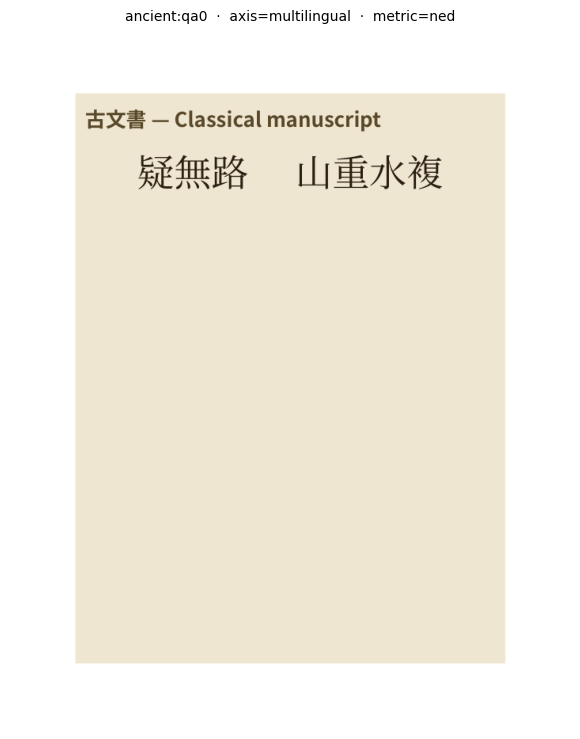

Q   : Transcribe the characters (top→bottom, right→left). Answer concisely, no explanation.
GT  : ['山重水複疑無路']
❌ qwen3_5-0.8b    : 古文書－Classical manuscript疑無路山重水複   (score=0.097)
❌ lfm2_5-vl-1.6b  : 古文書一 Classical manuscript  疑無路  山重水複   (score=0.083)
⚠  both models agree with EACH OTHER but not the GT → check the ground truth/metric
------------------------------------------------------------------------------------------


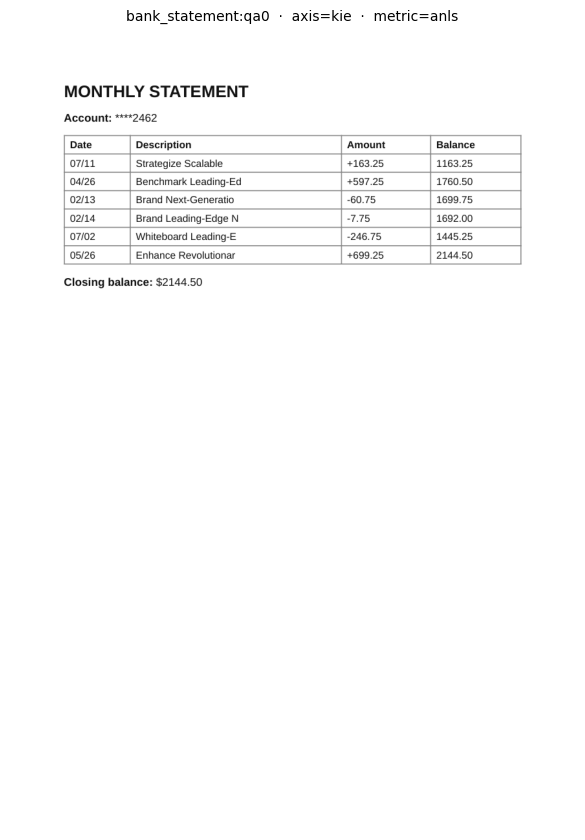

Q   : What is the closing balance? Answer concisely, no explanation.
GT  : ['$2144.50', '2144.50']
✅ qwen3_5-0.8b    : $2144.50   (score=1.0)
✅ lfm2_5-vl-1.6b  : $2144.50   (score=1.0)
------------------------------------------------------------------------------------------


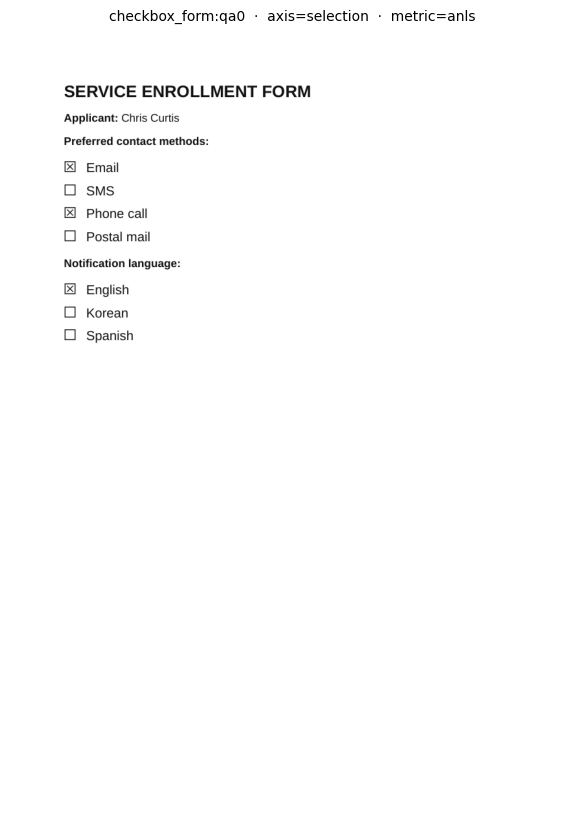

Q   : Which contact methods are checked? Answer concisely, no explanation.
GT  : ['Email, Phone call']
✅ qwen3_5-0.8b    : Email, Phone call   (score=1.0)
❌ lfm2_5-vl-1.6b  : Email, SMS   (score=0.0)
------------------------------------------------------------------------------------------


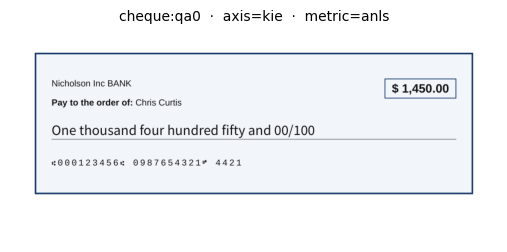

Q   : What is the numeric (courtesy) amount on the cheque? Answer concisely, no explanation.
GT  : ['1,450.00', '1450.00']
✅ qwen3_5-0.8b    : 1450   (score=0.571)
✅ lfm2_5-vl-1.6b  : 1,450.00.   (score=0.889)
------------------------------------------------------------------------------------------


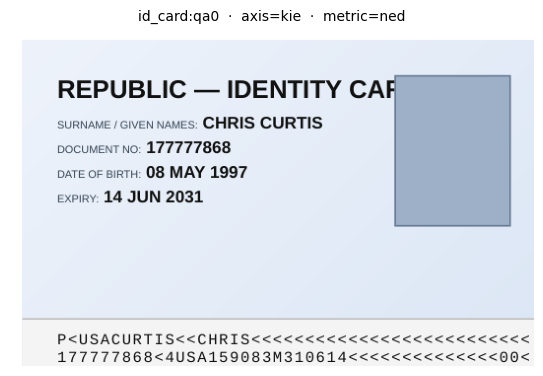

Q   : What is the document number? Answer concisely, no explanation.
GT  : ['177777868']
✅ qwen3_5-0.8b    : 177777868   (score=1.0)
✅ lfm2_5-vl-1.6b  : 1777777868.   (score=0.818)
------------------------------------------------------------------------------------------


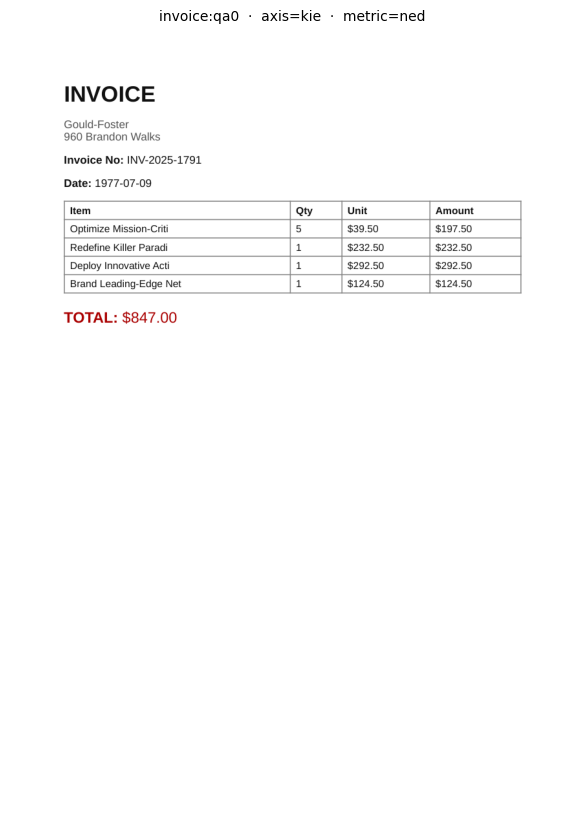

Q   : What is the invoice number? Answer concisely, no explanation.
GT  : ['INV-2025-1791']
✅ qwen3_5-0.8b    : INV-2025-1791   (score=1.0)
✅ lfm2_5-vl-1.6b  : INV-2025-1791   (score=1.0)
------------------------------------------------------------------------------------------


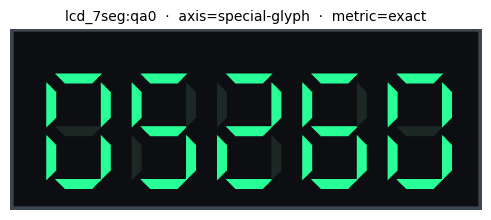

Q   : What number is on the display?
GT  : ['05260']
❌ qwen3_5-0.8b    : The number displayed on the display is:  **9988**  This is a digital clock showing the digits 9, 9, 8, and 8.   (score=0.0)
❌ lfm2_5-vl-1.6b  : 8888   (score=0.0)
------------------------------------------------------------------------------------------


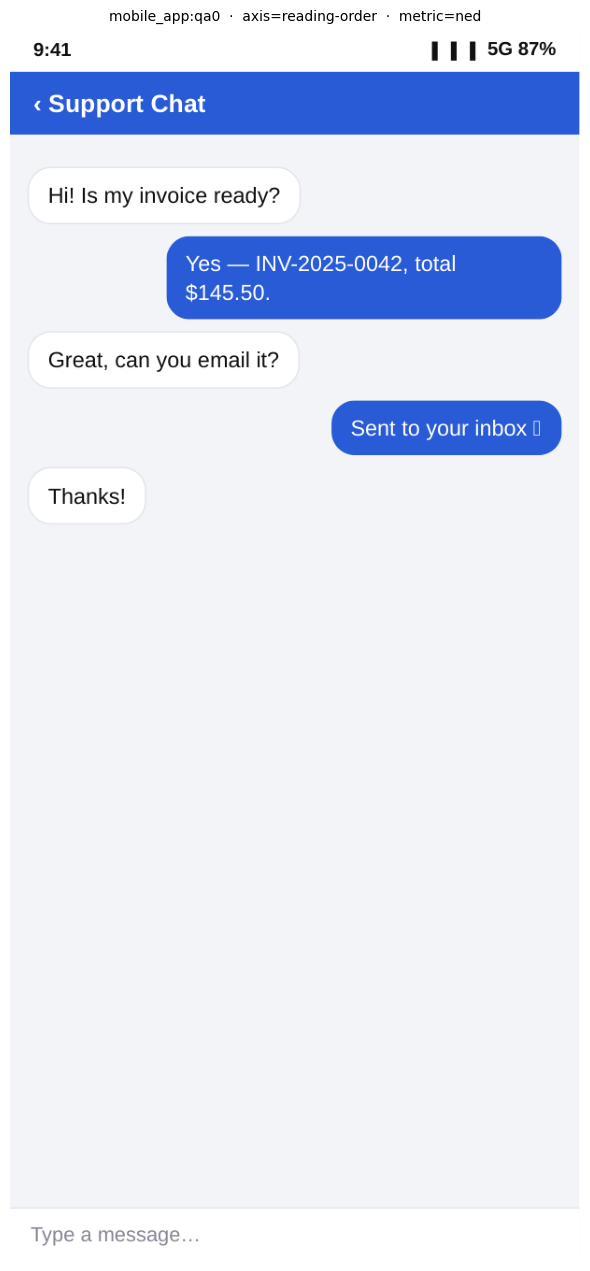

Q   : Transcribe the chat messages in order, one per line. Answer concisely, no explanation.
GT  : ['Hi! Is my invoice ready?\nYes — INV-2025-0042, total $145.50.\nGreat, can you email it?\nSent to your inbox ✅\nThanks!']
✅ qwen3_5-0.8b    : Hi! Is my invoice ready? Yes — INV-2025-0042, total $145.50. Great, can you email it? Sent to your inbox Thanks!   (score=0.982)
✅ lfm2_5-vl-1.6b  : Hi! Is my invoice ready? Yes — INV-2025-0042, total $145.50. Great, can you email it? Sent to your inbox Thanks!   (score=0.982)
------------------------------------------------------------------------------------------


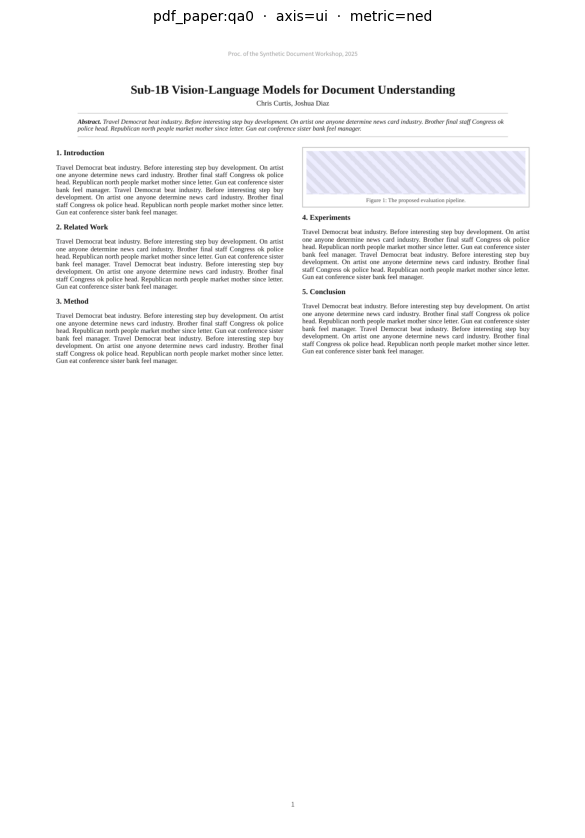

Q   : What is the paper title? Answer concisely, no explanation.
GT  : ['Sub-1B Vision-Language Models for Document Understanding']
✅ qwen3_5-0.8b    : Sub-1B Vision-Language Models for Document Understanding   (score=1.0)
✅ lfm2_5-vl-1.6b  : Sub-1B Vision-Language Models for Document Understanding   (score=1.0)
------------------------------------------------------------------------------------------


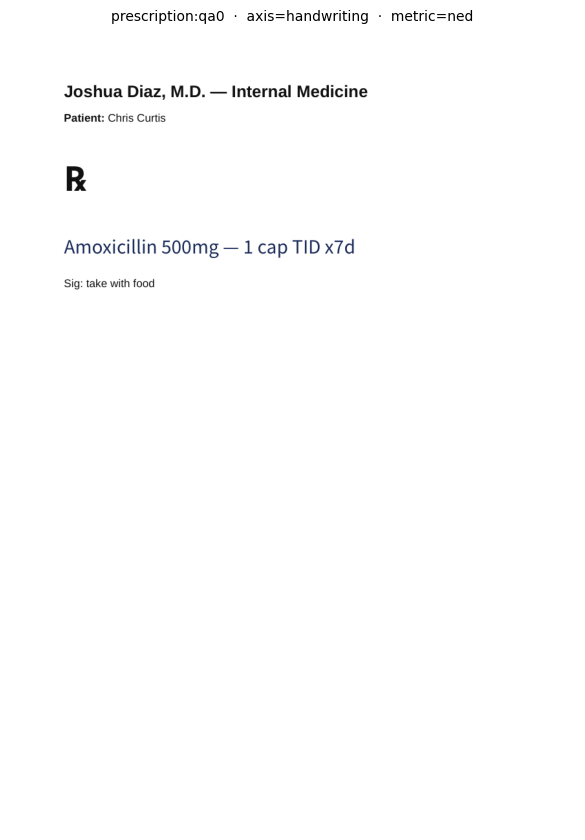

Q   : Transcribe the handwritten medication line. Answer concisely, no explanation.
GT  : ['Amoxicillin 500mg — 1 cap TID x7d']
✅ qwen3_5-0.8b    : Amoxicillin 500mg — 1 cap TID x7d   (score=1.0)
✅ lfm2_5-vl-1.6b  : Amoxicillin 500mg — 1 cap TID x7d   (score=1.0)
------------------------------------------------------------------------------------------


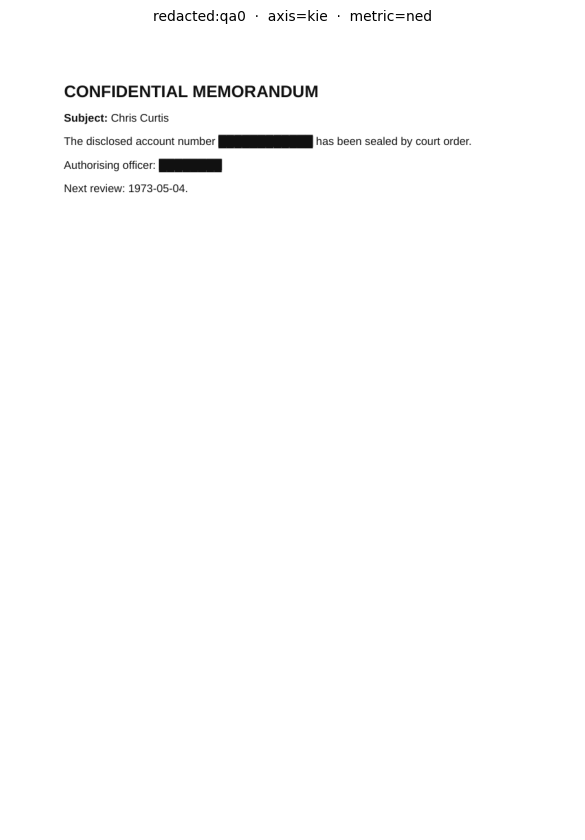

Q   : Who is the subject of the memo? Answer concisely, no explanation.
GT  : ['Chris Curtis']
✅ qwen3_5-0.8b    : Chris Curtis   (score=1.0)
✅ lfm2_5-vl-1.6b  : Chris Curtis   (score=1.0)
------------------------------------------------------------------------------------------


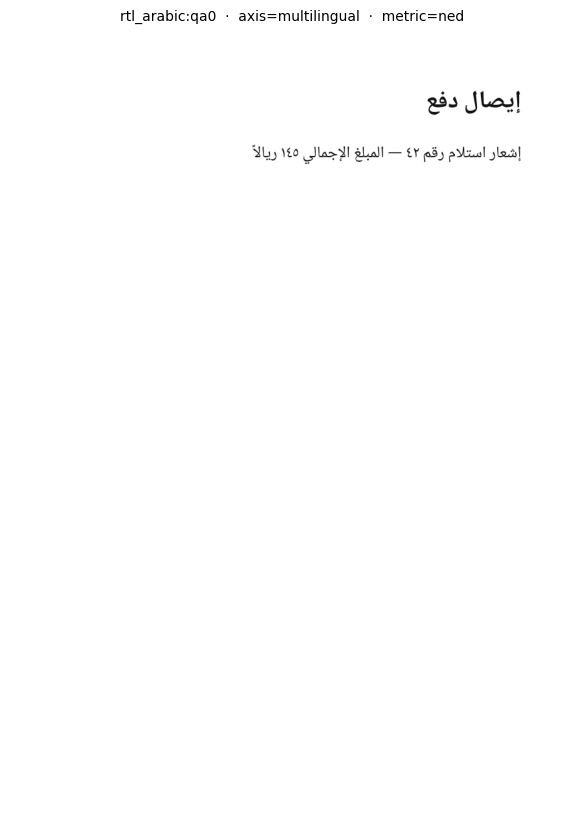

Q   : Transcribe the Arabic text in the image. Answer concisely, no explanation.
GT  : ['إشعار استلام رقم ٤٢ — المبلغ الإجمالي ١٤٥ ريالاً']
✅ qwen3_5-0.8b    : إصدار دفع إشراف استلام رقم ٤٢ - المبلغ الإجمالي ١٤٥ ريالاً   (score=0.776)
✅ lfm2_5-vl-1.6b  : إشعار دخول إشعار استنلاك رقم 34 - المباني الإجمالية 0 15 ريال   (score=0.574)
------------------------------------------------------------------------------------------


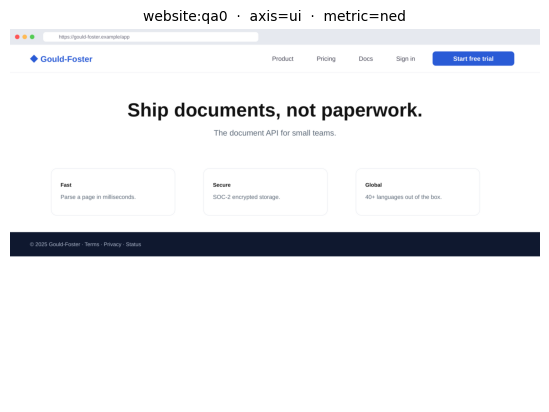

Q   : List the navigation menu items in order. Answer concisely, no explanation.
GT  : ['Product, Pricing, Docs, Sign in']
✅ qwen3_5-0.8b    : Product, Pricing, Docs, Sign in, Start free trial   (score=0.633)
✅ lfm2_5-vl-1.6b  : Product, Pricing, Docs, Sign in, Start free trial   (score=0.633)
------------------------------------------------------------------------------------------


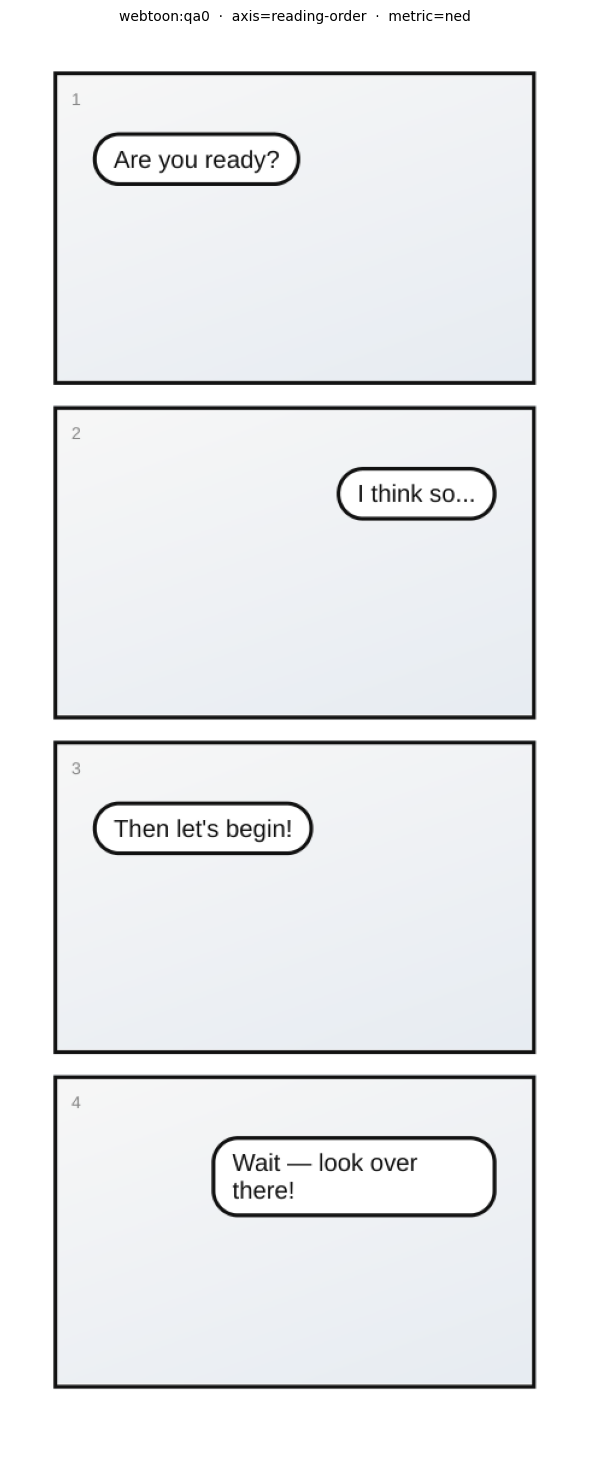

Q   : Transcribe the speech bubbles top to bottom, one per line. Answer concisely, no explanation.
GT  : ["Are you ready?\nI think so...\nThen let's begin!\nWait — look over there!"]
✅ qwen3_5-0.8b    : Are you ready? I think so... Then let's begin! Wait — look over there!   (score=1.0)
✅ lfm2_5-vl-1.6b  : Are you ready? I think so... Then let's begin! Wait — look over there!   (score=1.0)
------------------------------------------------------------------------------------------


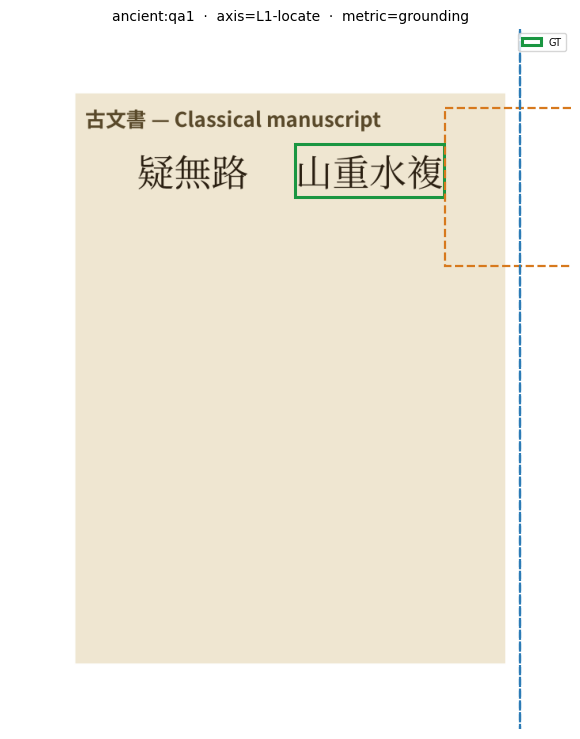

Q   : Where is the right-hand column located? Return its bounding box as [x1, y1, x2, y2] in pixel coordinates. The image is 709x886 pixels.
GT  : ['360,146,548,213;709,886']
❌ qwen3_5-0.8b    : The right-hand column is located at [550, 100, 999, 300].   (score=0.0)
❌ lfm2_5-vl-1.6b  : [645, 0, 645, 886]   (score=0.0)
------------------------------------------------------------------------------------------


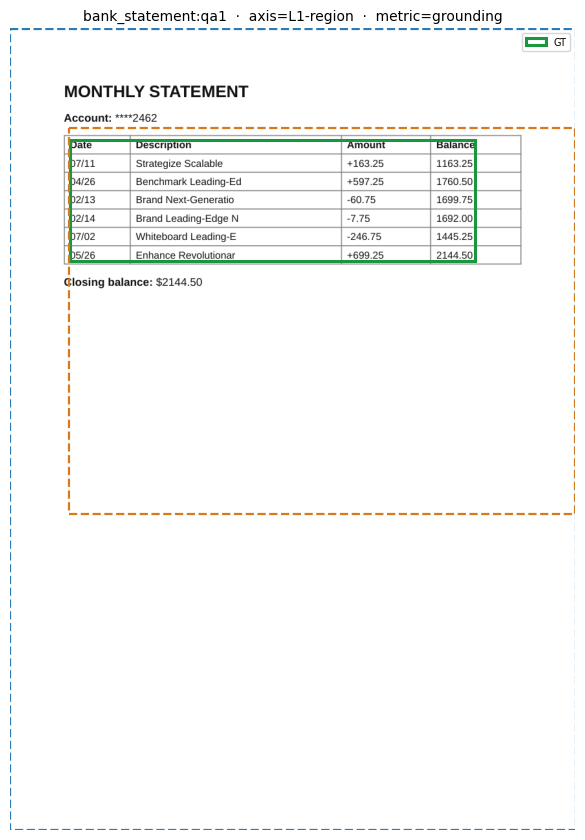

Q   : Where is the transaction table located? Return its bounding box as [x1, y1, x2, y2] in pixel coordinates. The image is 875x1241 pixels.
GT  : ['93,172,719,360;875,1241']
❌ qwen3_5-0.8b    : The transaction table is located at [103, 124, 999, 606].   (score=0.251)
❌ lfm2_5-vl-1.6b  : [0, 0, 875, 1241]   (score=0.108)
------------------------------------------------------------------------------------------


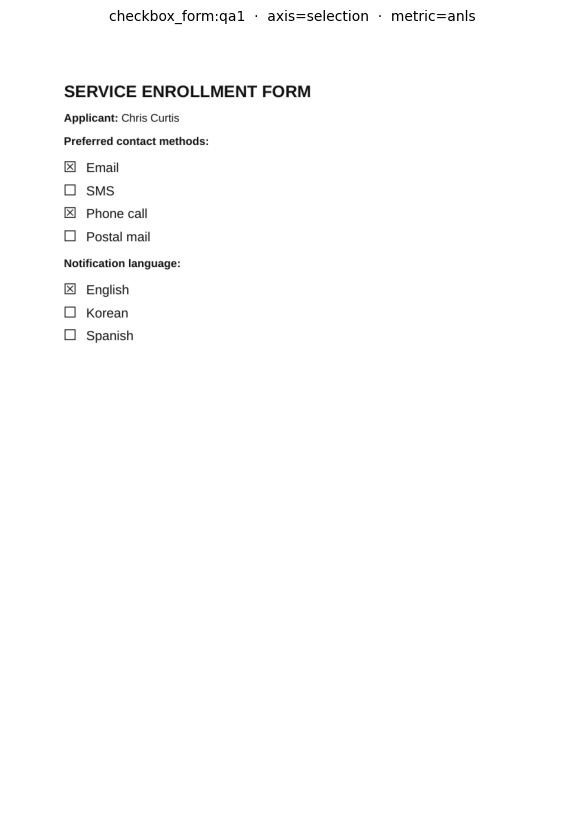

Q   : Which notification language is checked? Answer concisely, no explanation.
GT  : ['English']
✅ qwen3_5-0.8b    : English   (score=1.0)
✅ lfm2_5-vl-1.6b  : English   (score=1.0)
------------------------------------------------------------------------------------------


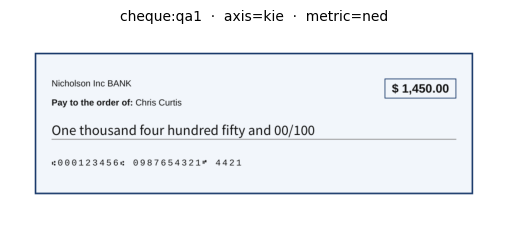

Q   : Who is the payee? Answer concisely, no explanation.
GT  : ['Chris Curtis']
✅ qwen3_5-0.8b    : Chris Curtis   (score=1.0)
✅ lfm2_5-vl-1.6b  : Chris Curtis.   (score=0.923)
------------------------------------------------------------------------------------------


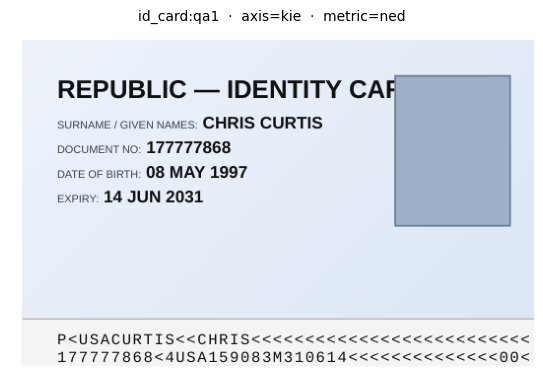

Q   : What is the cardholder's full name? Answer concisely, no explanation.
GT  : ['CHRIS CURTIS']
✅ qwen3_5-0.8b    : CHRIS CURTIS   (score=1.0)
✅ lfm2_5-vl-1.6b  : Chris Curtis.   (score=0.923)
------------------------------------------------------------------------------------------


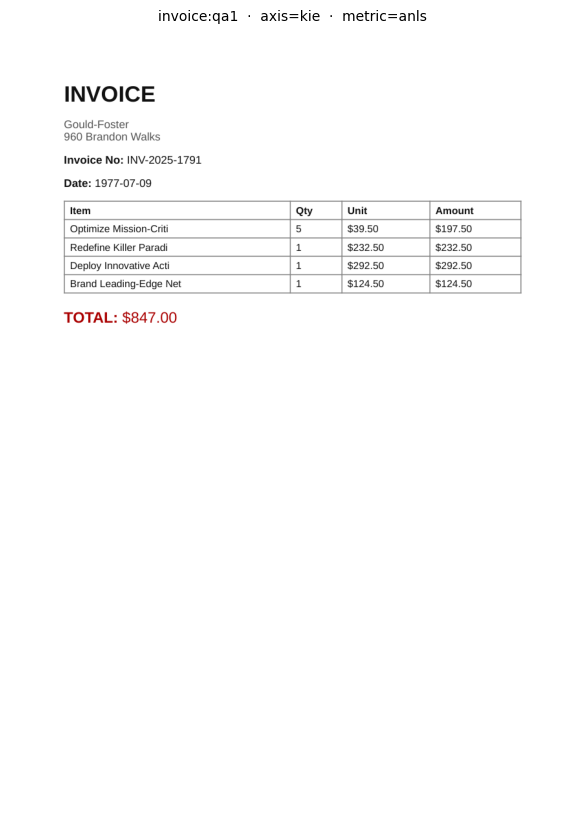

Q   : What is the total amount? Answer concisely, no explanation.
GT  : ['$847.00', '847.00', '847.00']
✅ qwen3_5-0.8b    : $847.00   (score=1.0)
✅ lfm2_5-vl-1.6b  : $847.00   (score=1.0)
------------------------------------------------------------------------------------------


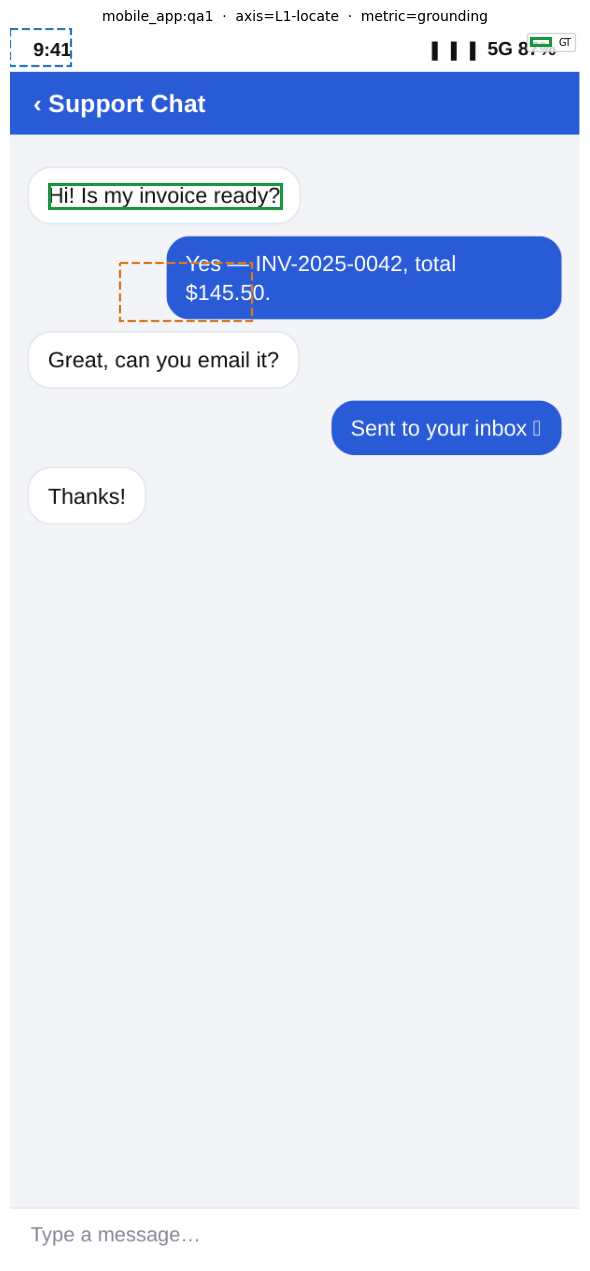

Q   : Where is the first chat message located? Return its bounding box as [x1, y1, x2, y2] in pixel coordinates. The image is 610x1319 pixels.
GT  : ['41,166,289,192;610,1319']
❌ qwen3_5-0.8b    : The bounding region for the first chat message is: [192, 190, 423, 237]   (score=0.0)
❌ lfm2_5-vl-1.6b  : [0, 0, 106, 30]   (score=0.0)
------------------------------------------------------------------------------------------


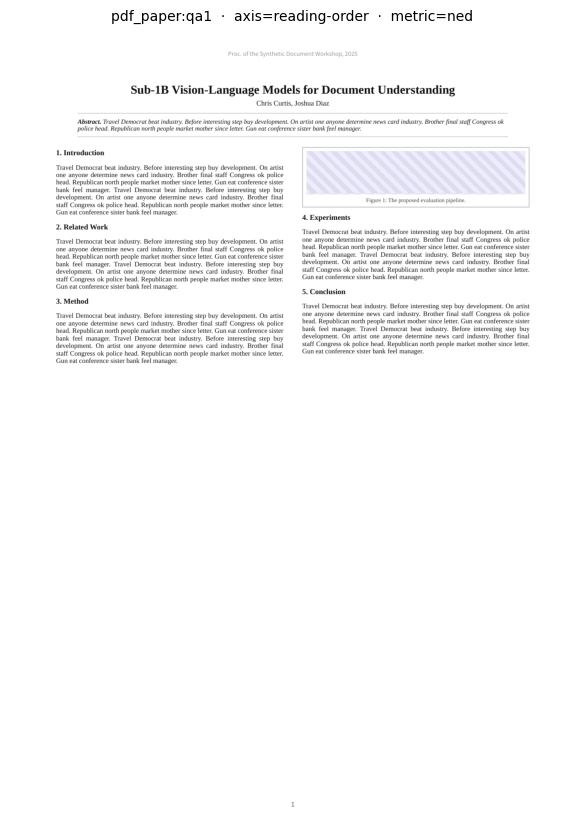

Q   : List the section headings in order. Answer concisely, no explanation.
GT  : ['1. Introduction; 2. Related Work; 3. Method; 4. Experiments; 5. Conclusion']
✅ qwen3_5-0.8b    : 1. Introduction 2. Related Work 3. Method 4. Experiments 5. Conclusion   (score=0.892)
✅ lfm2_5-vl-1.6b  : 1. Introduction 2. Related Work 3. Method 4. Experiments 5. Conclusion   (score=0.892)
------------------------------------------------------------------------------------------


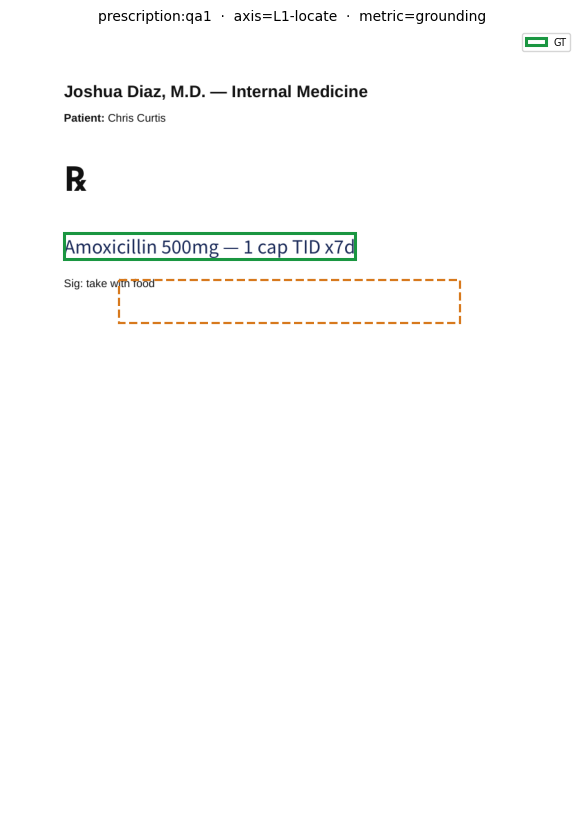

Q   : Where is the handwritten medication line located? Return its bounding box as [x1, y1, x2, y2] in pixel coordinates. The image is 875x1241 pi…
GT  : ['83,316,534,357;875,1241']
❌ qwen3_5-0.8b    : The handwritten medication line is located at [193, 313, 796, 367].   (score=0.0)
❌ lfm2_5-vl-1.6b  : [0.0, 0.0, 0.0, 0.0]   (score=0.0)
------------------------------------------------------------------------------------------


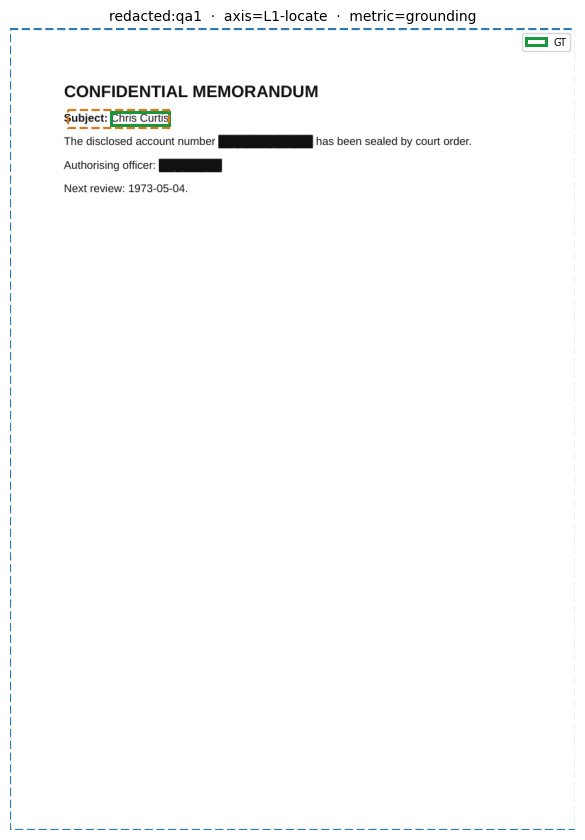

Q   : Where is the subject located? Return its bounding box as [x1, y1, x2, y2] in pixel coordinates. The image is 875x1241 pixels.
GT  : ['156,129,246,149;875,1241']
❌ qwen3_5-0.8b    : The subject is located at [102, 102, 280, 124].   (score=0.417)
❌ lfm2_5-vl-1.6b  : [0, 0, 875, 1241]   (score=0.002)
------------------------------------------------------------------------------------------


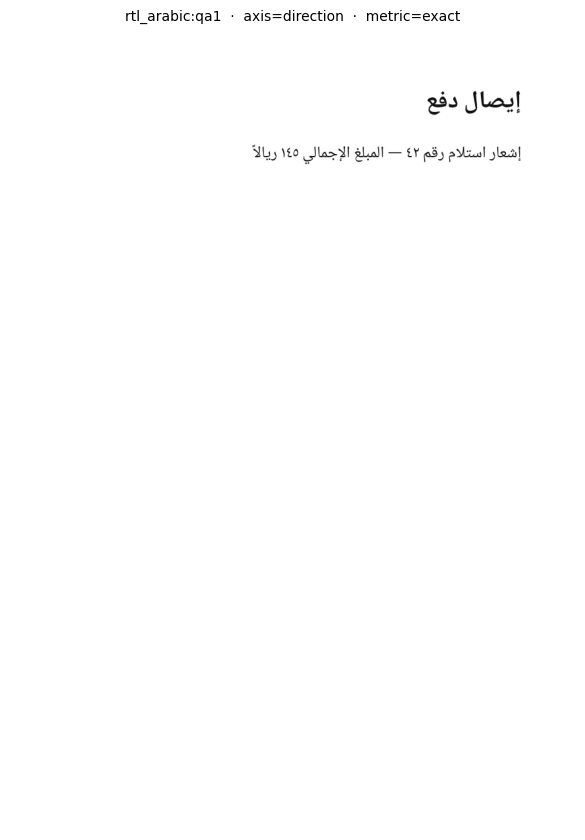

Q   : Is the text right-to-left or left-to-right? Answer concisely, no explanation.
GT  : ['right-to-left', 'rtl']
✅ qwen3_5-0.8b    : right-to-left   (score=1.0)
✅ lfm2_5-vl-1.6b  : Right-to-left.   (score=1.0)
------------------------------------------------------------------------------------------


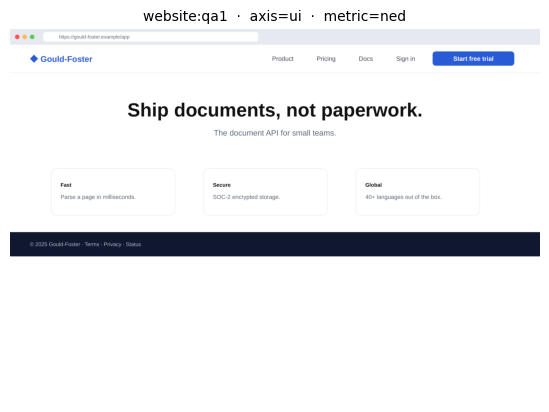

Q   : What is the main headline? Answer concisely, no explanation.
GT  : ['Ship documents, not paperwork.']
✅ qwen3_5-0.8b    : Ship documents, not paperwork.   (score=1.0)
✅ lfm2_5-vl-1.6b  : Ship documents, not paperwork.   (score=1.0)
------------------------------------------------------------------------------------------


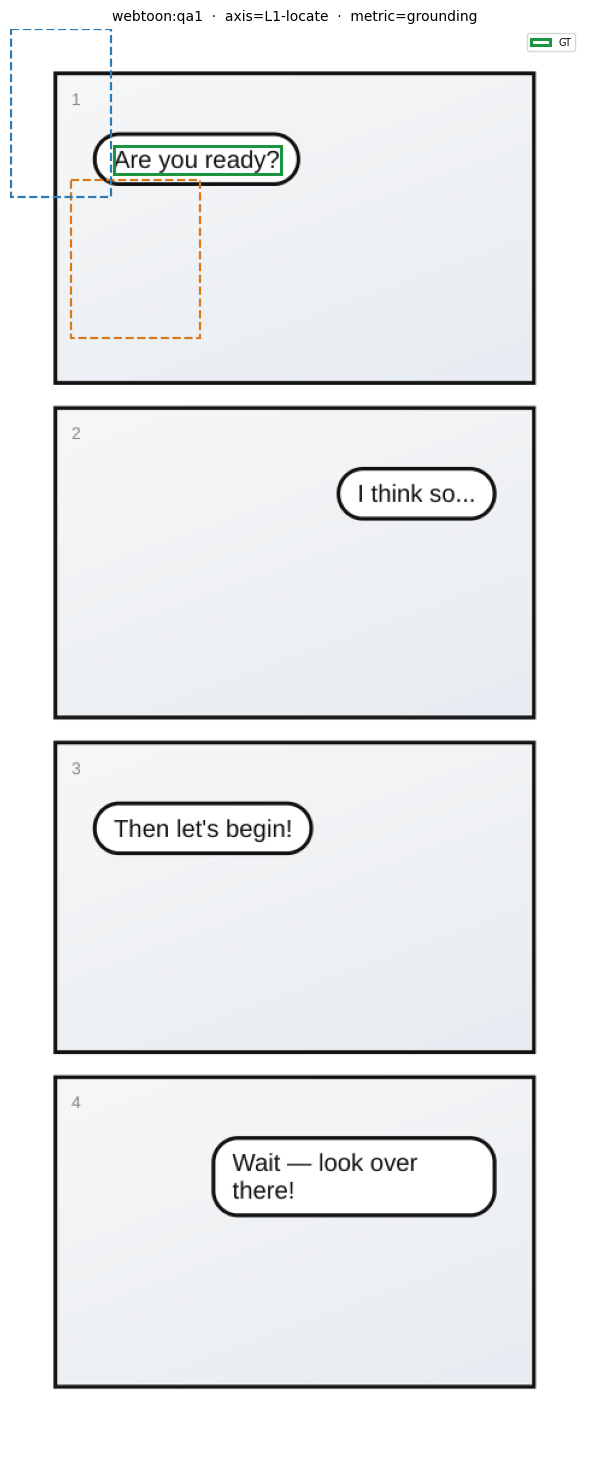

Q   : Where is the first speech bubble located? Return its bounding box as [x1, y1, x2, y2] in pixel coordinates. The image is 473x1182 pixels.
GT  : ['86,97,224,120;473,1182']
❌ qwen3_5-0.8b    : The bounding box for the first speech bubble is [106, 106, 333, 217].   (score=0.0)
❌ lfm2_5-vl-1.6b  : [0, 0, 176, 118]   (score=0.0)
------------------------------------------------------------------------------------------


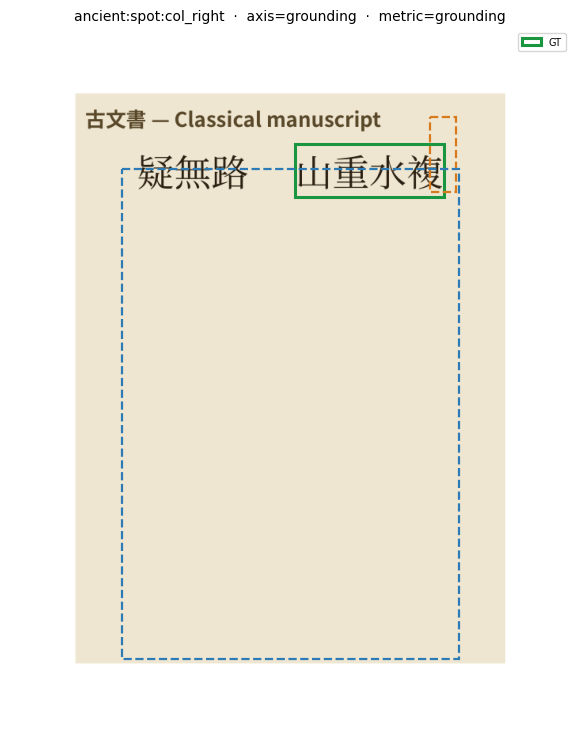

Q   : Return the bounding box of the col right as [x1, y1, x2, y2] in pixel coordinates. The image is 709x886 pixels.
GT  : ['360,146,548,213;709,886']
❌ qwen3_5-0.8b    : The right col is located at [531, 112, 564, 206].   (score=0.069)
❌ lfm2_5-vl-1.6b  : [0.2, 0.2, 0.8, 0.9]   (score=0.025)
------------------------------------------------------------------------------------------


In [13]:
def _short(t, n=140):
    t = (t or "").replace("\n", " ")
    return t if len(t) <= n else t[:n] + "…"

def show_scenario(r):
    img = Image.open(r["image"]).convert("RGB")
    fig, ax = plt.subplots(figsize=(6, 6*img.height/img.width)); ax.imshow(img); ax.set_axis_off()
    # grounding overlay: GT (green) vs each model's parsed box (qwen=orange, lfm=blue)
    if r["metric"] == "grounding":
        gb = parse_gold_box(r["gold"][0])
        if gb:
            (gx, sz) = gb
            ax.add_patch(mpatches.Rectangle((gx[0],gx[1]), gx[2]-gx[0], gx[3]-gx[1],
                         fill=False, edgecolor="#1a9641", lw=2.2, label="GT"))
            for k, col in [(KEYS[0], "#d7791d"), (KEYS[1], "#2c7bb6")]:
                pb = parse_pred_box(r[k], sz)
                if pb: ax.add_patch(mpatches.Rectangle((pb[0],pb[1]), pb[2]-pb[0], pb[3]-pb[1],
                                    fill=False, edgecolor=col, lw=1.6, linestyle="--"))
        ax.legend(fontsize=7, loc="upper right")
    ax.set_title(f"{r['id']}  ·  axis={r['axis']}  ·  metric={r['metric']}", fontsize=10)
    plt.tight_layout(); plt.show()

    print(f"Q   : {_short(r['q'])}")
    print(f"GT  : {r['gold']}")
    if r["meta"].get("rationale"): print(f"why : {_short(r['meta']['rationale'])}")
    for k in KEYS:
        mark = "✅" if r[k+"_score"] >= 0.5 else "❌"
        print(f"{mark} {k:16}: {_short(r[k])}   (score={r[k+'_score']})")
    # quick flaw hint inline
    if r[KEYS[0]+"_score"] < 0.5 and r[KEYS[1]+"_score"] < 0.5:
        agree = score_sample("anls", r[KEYS[0]], [r[KEYS[1]]])
        if agree >= 0.6 and r[KEYS[0]].strip():
            print("⚠  both models agree with EACH OTHER but not the GT → check the ground truth/metric")
    print("-"*90)

for r in REC:
    show_scenario(r)

## 3. GT-flaw suspects (ranked)

Rules: **(A)** both models score &lt;0.5 *and* agree with each other (ANLS ≥ 0.6) → the gold/metric
is the likely problem; **(B)** the gold string is contained in a prediction yet scored 0 → a
metric/normalisation artefact (not a wrong answer). Eyeball these first.

In [14]:
def agreement(a, b): return score_sample("anls", a or "", [b or ""])

suspects = []
for r in REC:
    sA, sB = r[KEYS[0]+"_score"], r[KEYS[1]+"_score"]
    pA, pB = r[KEYS[0]], r[KEYS[1]]
    gold = " | ".join(r["gold"])
    if sA < 0.5 and sB < 0.5 and pA.strip() and agreement(pA, pB) >= 0.6:
        suspects.append((agreement(pA, pB), "A: models agree, GT differs", r))
    elif any(g.strip().lower() in (pA+pB).lower() for g in r["gold"] if g.strip()) and max(sA, sB) < 0.5:
        suspects.append((0.5, "B: gold ⊆ prediction but scored 0 (metric)", r))

suspects.sort(key=lambda x: -x[0])
print(f"{len(suspects)} suspect scenario(s):\n")
for conf, why, r in suspects:
    print(f"[{why}]  {r['id']}  (axis={r['axis']}, metric={r['metric']})")
    print(f"   Q   : {_short(r['q'], 90)}")
    print(f"   GT  : {r['gold']}")
    print(f"   {KEYS[0]}: {_short(r[KEYS[0]], 70)}  | {KEYS[1]}: {_short(r[KEYS[1]], 70)}")
    print()
if not suspects:
    print("No obvious GT/metric flaws by these rules — but still skim the cards above.")

1 suspect scenario(s):

[A: models agree, GT differs]  ancient:qa0  (axis=multilingual, metric=ned)
   Q   : Transcribe the characters (top→bottom, right→left). Answer concisely, no explanation.
   GT  : ['山重水複疑無路']
   qwen3_5-0.8b: 古文書－Classical manuscript疑無路山重水複  | lfm2_5-vl-1.6b: 古文書一 Classical manuscript  疑無路  山重水複

